# Masking Variable-Length Time Series

Simulators often produce sequences of different lengths, while a neural network needs a dense, rectangular array.
The usual solution is to pad every sequence to a common length and to carry a _mask_ that records which entries are real.
In this tutorial, we follow such a mask from the simulator through the adapter into the summary network, and we measure how much it is worth.

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt

import bayesflow as bf

keras.utils.set_random_seed(1)
rng = np.random.default_rng(1)

INFO:bayesflow:Using backend 'jax'


## Toy Problem

We will infer the drift $\mu$ and the log volatility $\log \sigma$ of a random walk:

$$x_t = x_{t-1} + \mu \, \Delta t + \sigma \sqrt{\Delta t} \, \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, 1)$$

Each trajectory is observed for a random number of steps and is then padded out to `MAX_LENGTH`.
Note that the pad value is arbitrary. Once the mask is in place, padded entries never influence the result.

In [2]:
MIN_LENGTH, MAX_LENGTH = 15, 60
PAD_VALUE = 0.0
DT = 0.1


def prior():
    drift = rng.normal(0.0, 1.0)
    log_scale = rng.normal(0.0, 0.5)
    return dict(drift=drift, log_scale=log_scale)


def observation_model(drift, log_scale):
    length = rng.integers(MIN_LENGTH, MAX_LENGTH + 1)
    steps = drift * DT + np.exp(log_scale) * np.sqrt(DT) * rng.normal(size=length)
    trajectory = np.cumsum(steps)

    x = np.full((MAX_LENGTH, 1), PAD_VALUE, dtype=np.float32)
    x[:length, 0] = trajectory

    observed = np.zeros(MAX_LENGTH, dtype=np.float32)
    observed[:length] = 1.0

    return dict(x=x, observed=observed)


simulator = bf.make_simulator([prior, observation_model])

We can simulate a few datasets and inspect their shapes:

In [3]:
batch = simulator.sample(4)

for key, value in batch.items():
    print(f"{key:12s} {str(value.shape):14s} {value.dtype}")

drift        (4, 1)         float64
log_scale    (4, 1)         float64
x            (4, 60, 1)     float32
observed     (4, 60)        float32


So `x` is dense and rectangular, while `observed` records how much of each row is real.
We can visualize a few trajectories to see where the padding begins:

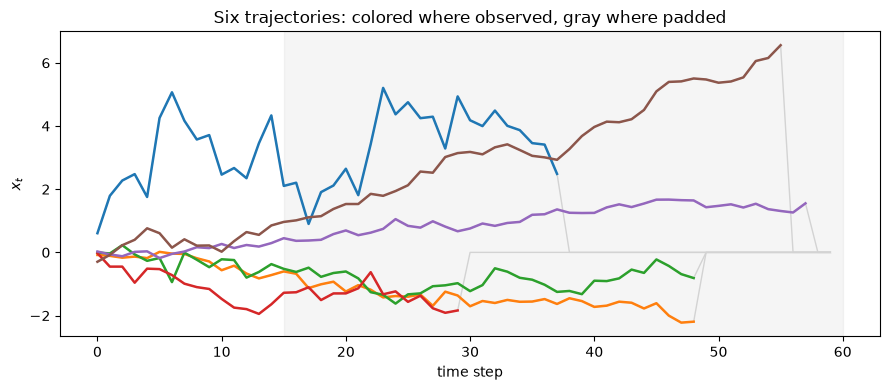

In [4]:
demo = simulator.sample(6)

fig, ax = plt.subplots(figsize=(9, 4))
for i in range(len(demo["x"])):
    length = int(demo["observed"][i].sum())
    ax.plot(demo["x"][i, :, 0], color="lightgray", lw=1, zorder=1)
    ax.plot(np.arange(length), demo["x"][i, :length, 0], lw=1.8, zorder=2)

ax.axvspan(MIN_LENGTH, MAX_LENGTH, color="black", alpha=0.04, zorder=0)
ax.set_xlabel("time step")
ax.set_ylabel("$x_t$")
ax.set_title("Six trajectories: colored where observed, gray where padded")
fig.tight_layout()

## Pre-processing with the Adapter

BayesFlow recognizes four canonical mask keys in the adapted batch:

| canonical key | forwarded to | meaning |
|---|---|---|
| `summary_mask` | summary network | padding mask, `1` = real time step |
| `summary_attention_mask` | summary network | explicit attention mask, takes precedence |
| `inference_mask` | inference network | padding mask |
| `inference_attention_mask` | inference network | explicit attention mask |

To route our mask, we therefore only have to rename it to `summary_mask`.

In [5]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series("x")
    .concatenate(["drift", "log_scale"], into="inference_variables")
    .rename("x", "summary_variables")
    .rename("observed", "summary_mask")
)

adapted = adapter(simulator.sample(4))

for key, value in adapted.items():
    print(f"{key:20s} {str(value.shape):16s} {value.dtype}")

inference_variables  (4, 2)           float32
summary_variables    (4, 60, 1)       float32
summary_mask         (4, 60)          float32


The shapes are the part that is easy to get wrong.
`summary_variables` has shape `(batch, time, features)`, while `summary_mask` has shape `(batch, time)` and carries no feature axis.
The mask marks whole time steps as present or absent, where `1` means keep.
A mask that does have a feature axis is a _missingness_ mask, which is a different tool (see `Adapter.nan_to_num`).

Note that we only need `summary_attention_mask` if we want to control the full `(batch, heads, time, time)` attention pattern ourselves.
It takes precedence over anything derived from `summary_mask`.

## What the Mask Does

Once `summary_mask` is part of the batch, it changes three things.
They differ in how easily the network could compensate for a missing mask.

- _Attention._ Padded steps are excluded as attention keys. Without the mask, the model takes a softmax over `MAX_LENGTH` keys, of which a varying number are padding. It can learn to suppress them, so this part is close to free.
- _Pooling._ The summary average divides by the number of real steps instead of by `MAX_LENGTH`. This part cannot be learned away. Even if the network drove every padded position to zero, the pooled vector would still be scaled by `length / MAX_LENGTH`, which varies from dataset to dataset, and the `Dense` output projector applies the same weights to every dataset.
- _Standardization._ The running moments accumulate over real steps only. Padded entries are all identical, so including them pulls the mean toward the pad value and shrinks the variance.

The effect on standardization is easy to see directly:

In [6]:
def moments(use_mask, data):
    approximator = bf.ContinuousApproximator(
        adapter=adapter,
        inference_network=bf.networks.CouplingFlow(depth=2),
        summary_network=bf.networks.TimeSeriesTransformer(
            summary_dim=8, embed_dims=(16, 16), num_heads=(2, 2)
        ),
        standardize="all",
    )
    approximator.build_from_data(data)

    kwargs = dict(
        inference_variables=data["inference_variables"],
        summary_variables=data["summary_variables"],
        stage="training",
    )
    if use_mask:
        kwargs["summary_mask"] = data["summary_mask"]
    approximator.compute_metrics(**kwargs)

    layer = approximator.standardizer.standardize_layers["summary_variables"]
    return (
        float(keras.ops.convert_to_numpy(layer.moving_mean[0])[0]),
        float(keras.ops.convert_to_numpy(layer.moving_std(0))[0]),
        int(keras.ops.convert_to_numpy(layer.count[0])),
    )


raw = simulator.sample(512)
data = adapter(raw)

# reference: real steps only, pooled across trajectories
real = np.concatenate([raw["x"][i, : int(raw["observed"][i].sum()), 0] for i in range(len(raw["x"]))])

print(f"{'':16s} {'mean':>9s} {'std':>9s} {'count':>9s}")
print(f"{'real steps':16s} {real.mean():9.4f} {real.std():9.4f} {len(real):9d}")
for label, use_mask in [("with mask", True), ("without mask", False)]:
    mean, std, count = moments(use_mask, data)
    print(f"{label:16s} {mean:9.4f} {std:9.4f} {count:9d}")

                      mean       std     count
real steps         -0.1935    3.3972     18786
with mask          -0.1935    3.3972     18786
without mask       -0.1183    2.6583     30720


The masked moments match the padding-free reference exactly.
The unmasked ones count the full 512 by 60 grid and clearly underestimate the standard deviation.

## Training

Apart from the mask, this is an ordinary BayesFlow workflow.

In [7]:
keras.utils.set_random_seed(7)
rng = np.random.default_rng(1)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=bf.networks.TimeSeriesTransformer(summary_dim=16, embed_dims=(32, 32), num_heads=(2, 2)),
    inference_network=bf.networks.CouplingFlow(depth=4),
    standardize="all",
    inference_variables=["drift", "log_scale"],
)

history = workflow.fit_online(epochs=15, batch_size=64, num_batches_per_epoch=50)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 2.8085
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.4656
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 2.3754
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 2.3508
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 2.3643
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 2.2722
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 2.1976
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.1730
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 2.2124
Epoch 10/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 2.1532
Epoch 11/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 2.2012
Epoch 12/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 2.1626
Epoch 13/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2.1605
Epoch 14/15
50/50 ━━━━━━━━━━━━━━━━━━

## Does the Network Simply Learn to Ignore the Padding?

Partly, but not entirely.
To see how much the mask contributes, we train a second workflow from the same seed on the same simulator.
The only difference is that its adapter drops the mask.

In [8]:
keras.utils.set_random_seed(7)
rng = np.random.default_rng(1)

unmasked_adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series("x")
    .concatenate(["drift", "log_scale"], into="inference_variables")
    .rename("x", "summary_variables")
    .drop("observed")
)

unmasked = bf.BasicWorkflow(
    simulator=simulator,
    adapter=unmasked_adapter,
    summary_network=bf.networks.TimeSeriesTransformer(summary_dim=16, embed_dims=(32, 32), num_heads=(2, 2)),
    inference_network=bf.networks.CouplingFlow(depth=4),
    standardize="all",
    inference_variables=["drift", "log_scale"],
)

unmasked_history = unmasked.fit_online(epochs=15, batch_size=64, num_batches_per_epoch=50)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 2.8322
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 2.6058
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 2.4766
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 2.4674
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 2.4597
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.4316
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 2.3492
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 2.3353
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 2.3848
Epoch 10/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 2.3157
Epoch 11/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 2.3540
Epoch 12/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.3273
Epoch 13/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.3203
Epoch 14/15
50/50 ━━━━━━━━━━━━━━━━━━

We compare both workflows on the same held-out datasets:

In [9]:
rng = np.random.default_rng(99)
test = simulator.sample(500)

truth = np.concatenate([test["drift"], test["log_scale"]], axis=-1)
is_short = test["observed"].sum(axis=1) <= 25

print(f"{'':14s} {'log density':>12s} {'RMSE mu':>9s} {'RMSE log s':>11s} {'RMSE short':>11s} {'RMSE long':>10s}")
for label, trained in [("with mask", workflow), ("without mask", unmasked)]:
    log_density = trained.log_prob(test).mean()
    draws = trained.sample(conditions=test, num_samples=200)
    posterior_mean = np.concatenate([draws["drift"].mean(axis=1), draws["log_scale"].mean(axis=1)], axis=-1)
    error = posterior_mean - truth

    rmse = np.sqrt((error**2).mean(axis=0))
    rmse_short = np.sqrt((error[is_short] ** 2).mean())
    rmse_long = np.sqrt((error[~is_short] ** 2).mean())
    print(
        f"{label:14s} {log_density:12.3f} {rmse[0]:9.4f} {rmse[1]:11.4f} "
        f"{rmse_short:11.4f} {rmse_long:10.4f}"
    )

                log density   RMSE mu  RMSE log s  RMSE short  RMSE long
INFO:bayesflow:Computing log probability completed in 2.88 seconds.
INFO:bayesflow:Sampling completed in 2.07 seconds.
with mask            -1.459    0.5888      0.4803      0.5532     0.5329
INFO:bayesflow:Computing log probability completed in 0.14 seconds.
INFO:bayesflow:Sampling completed in 0.90 seconds.
without mask         -1.625    0.6516      0.4818      0.5998     0.5656


Here the mask is worth roughly 0.17 nats of held-out log density.
The cost of dropping it falls almost entirely on the drift, whose RMSE is about 10% worse, while the volatility estimate is unchanged.
This asymmetry is what we expect from the pooling denominator, because a scale factor of `length / MAX_LENGTH` distorts a mean-like quantity much more than a spread-like one.
The gap is also wider for short sequences, which carry the most padding.

So the network does learn to cope to some degree, but not completely, and what it fails to recover is what the arithmetic predicts.
The ordering is stable across seeds, while the magnitudes vary somewhat.

## Evaluation

We plot the default diagnostics to assess whether training has been successful.
Please refer to the introductory notebooks for details on the interpretation.

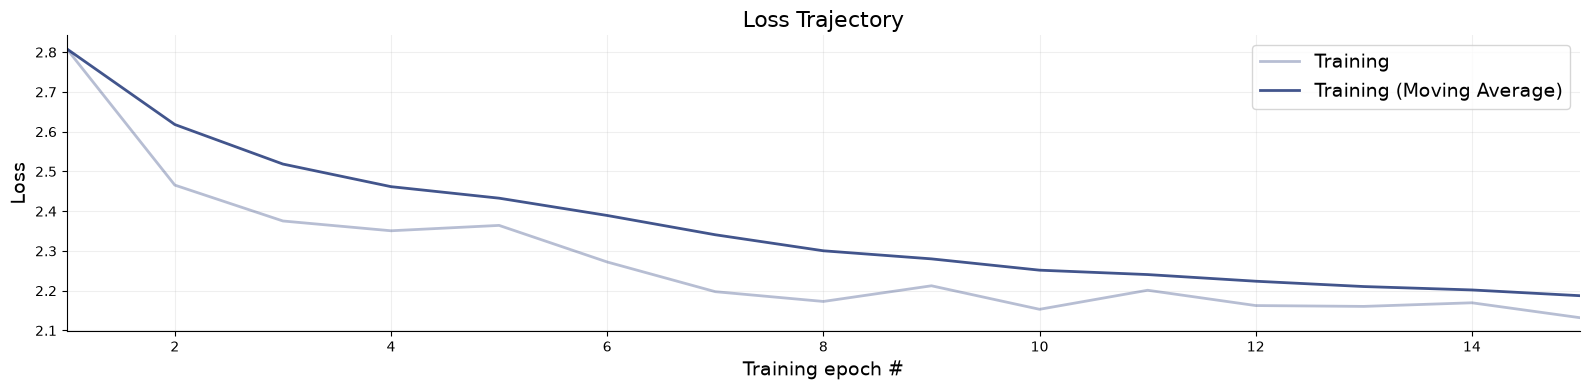

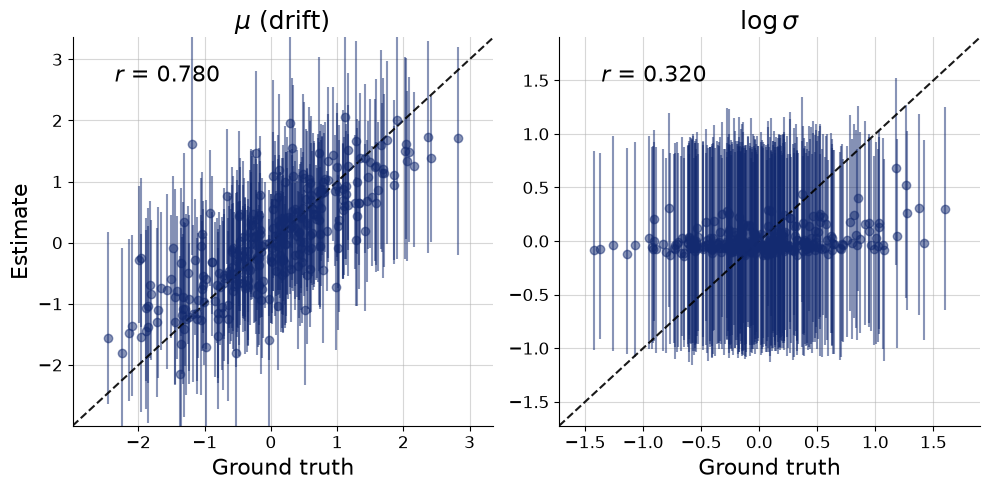

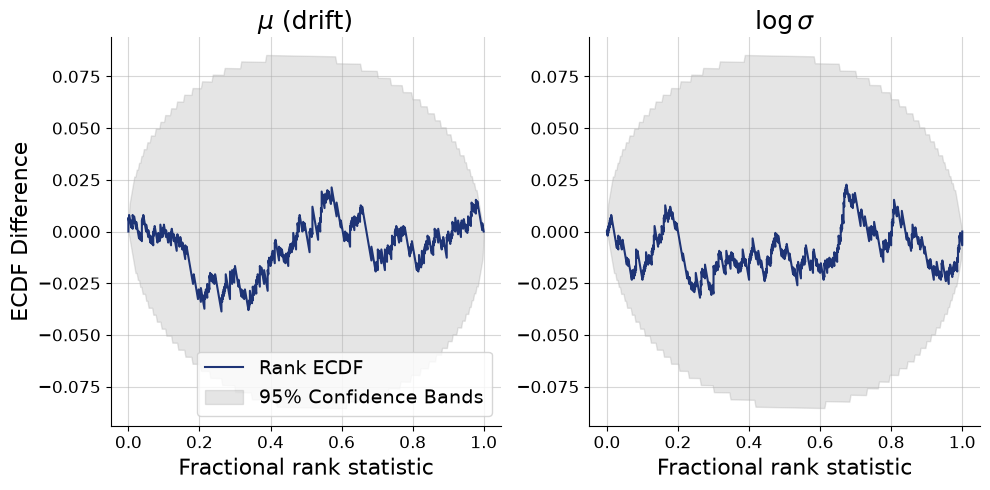

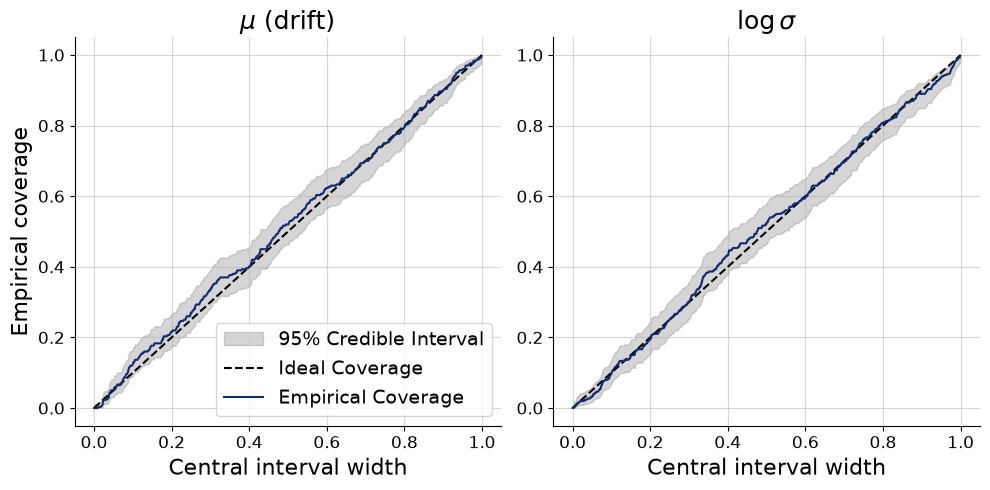

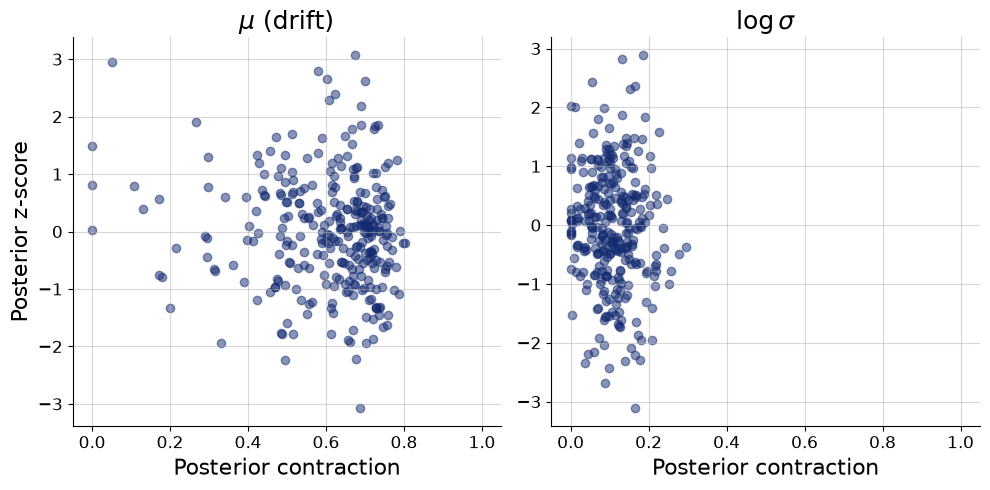

In [10]:
figures = workflow.plot_default_diagnostics(
    test_data=300,
    num_samples=500,
    variable_names=[r"$\mu$ (drift)", r"$\log \sigma$"],
)

Finally, we inspect the joint posterior for a single held-out dataset, together with the values that generated it:

INFO:bayesflow:Sampling completed in 2.44 seconds.


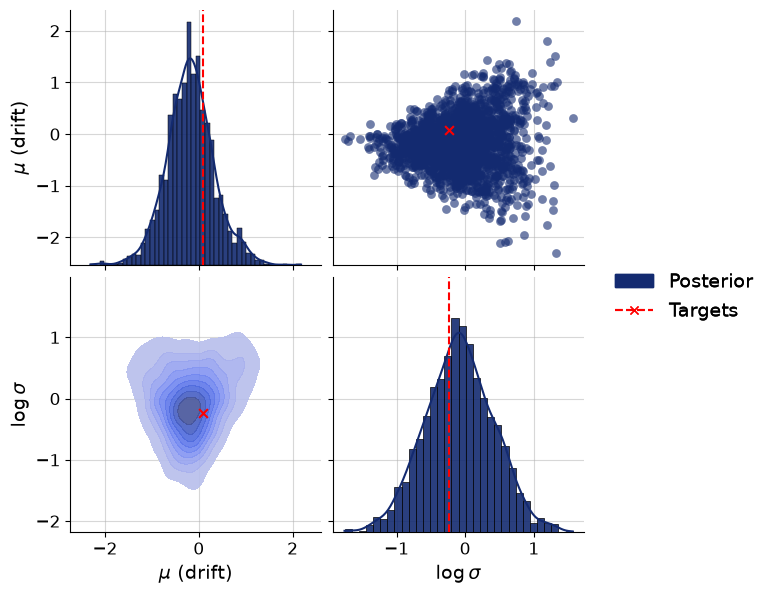

In [11]:
one = {key: value[:1] for key, value in test.items()}
draws = workflow.sample(conditions=one, num_samples=2000)

grid = bf.diagnostics.plots.pairs_posterior(
    estimates=draws,
    targets={key: one[key] for key in ["drift", "log_scale"]},
    variable_names=[r"$\mu$ (drift)", r"$\log \sigma$"],
)